# 06 — Proposed v2 features: counts, rates and evidence spans

**Goal.** Show a concrete alternative to the v1 categorical features, and get a preliminary
estimate of whether it is worth scaling up.

**The problem with v1.** Each feature is a 3–5 level categorical label such as
`narrative_coherence = simple_sentences`. Notebook 03 showed what that costs: some features
collapse almost everyone into one level, several declared levels are never used at all, and
a coarse label discards most of the evidence that produced it.

**The v2 idea.** Ask the model for three things instead of one label:

1. **counts** — how many hedges, how many named entities, how many locative phrases;
2. **evidence spans** — the verbatim words that produced each count;
3. and let the *harness* compute **rates** (per 100 words), never the model.

Why rates matter: notebook 01 showed the positive group produces shorter transcripts, so every
raw count is partly a length measurement. Reporting counts and rates side by side is what
separates a linguistic construct from a word counter.

Why evidence spans matter: a span can be checked against the transcript. If the model quotes
something that is not there, the count is fabricated — and we can measure how often that
happens.

**The nine constructs** come from the lexical analysis at the end of notebook 04, i.e. from
what actually separates the groups in this corpus.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

RUN_LLM = False                       # True = call the model; False = use the rule-based proxy below
BASE_URL = "https://llm.vse.cz/ollama/v1/"
API_KEY  = "ollama"
MODEL    = "qwen3.6:35b"

corpus = pd.read_csv("outputs/corpus.csv")
train = corpus[corpus.split == "train"].reset_index(drop=True)
extra = corpus[corpus.split == "train.extra"].reset_index(drop=True)
y = train.label.astype(int).values
print(f"train {len(train)} docs ({y.sum()} positive) | unlabelled pool {len(extra)} docs")

train 241 docs (70 positive) | unlabelled pool 86 docs


## The v2 extraction prompt

Note what is *not* in it: no mention of groups, classes, diagnoses, health or ability. The
model is asked to annotate, not to evaluate.

In [2]:
# NOTE: this V2_PROMPT is an EARLY DESIGN DRAFT (sha256[:16] 342079dbd9665fd1),
# not the frozen prompt used for the thesis result. The frozen prompt
# (sha256[:16] f52aae5d939d620e) lives in helpers.py and notebooks 08-11.
# This notebook is the V2 feature *proposal*; keep the draft as-is for the record.
V2_PROMPT = """\
You are annotating a transcript of spontaneous Czech speech. A person was shown a drawing of a
lakeshore scene and asked to describe it aloud. The text is an automatic transcription.

Your job is to COUNT observable linguistic events and QUOTE the evidence for each count.
You are an annotator, not an evaluator.

RULES
- Quote evidence verbatim from the transcript, in Czech. Never translate or paraphrase.
- If a category has no instances, return an empty list. Empty is a valid answer.
- Never infer anything about the speaker: not health, ability, age, education or mood.
- Do not compare this speaker to anyone else or to any norm.
- Count occurrences, not impressions. Two hedges in one sentence are two entries.
- Return only JSON.

CATEGORIES
1.  named_entities - every distinct object, creature or person named. Lemmatise; list each once.
2.  specific_action_verbs - verbs naming a particular manner of action (jumps, flies, peeks out).
3.  generic_verbs - verbs of bare existence, possession, location or unspecified movement.
4.  complete_propositions - integer. Clauses with explicit subject AND predicate AND one more argument.
5.  locative_expressions - phrases placing something somewhere (on the shore, in the sky, on the left).
6.  regions_referenced - which of "water", "land", "sky" are explicitly referred to.
7.  hedge_spans - expressions of uncertainty about what is depicted (maybe, probably, I don't know).
8.  deictic_spans - places where the speaker points instead of naming (there, that, that thing).
9.  metacomment_spans - remarks about the speaker's own describing or remembering, or about the task.
10. repeated_content_lemmas - content words used more than once, with counts.
11. self_corrections - integer. Restarts, replacements or retractions.
12. diminutive_or_affective_forms - noun forms marked as diminutive or affectionate.
13. quantity_expressions - numerals or quantifiers applied to things in the scene.

Return exactly this JSON and nothing else:
{"named_entities": [], "specific_action_verbs": [], "generic_verbs": [],
 "complete_propositions": 0, "locative_expressions": [], "regions_referenced": [],
 "hedge_spans": [], "deictic_spans": [], "metacomment_spans": [],
 "repeated_content_lemmas": [{"lemma": "", "count": 0}], "self_corrections": 0,
 "diminutive_or_affective_forms": [], "quantity_expressions": []}
"""
for w in ["group", "class", "diagnos", "impair", "patient", "healthy"]:
    assert w not in V2_PROMPT.lower(), f"prompt leaks label information: {w}"
print("prompt is label-blind — OK")

prompt is label-blind — OK


## Turning one response into a modelling row

This is where rates are computed. The model never sees or reports transcript length.

In [3]:
LIST_FIELDS = ["named_entities", "specific_action_verbs", "generic_verbs", "locative_expressions",
               "regions_referenced", "hedge_spans", "deictic_spans", "metacomment_spans",
               "diminutive_or_affective_forms", "quantity_expressions"]
SPAN_FIELDS = ["specific_action_verbs", "generic_verbs", "locative_expressions", "hedge_spans",
               "deictic_spans", "metacomment_spans", "diminutive_or_affective_forms",
               "quantity_expressions"]
VALID_REGIONS = {"water", "land", "sky"}


def validate(obj):
    """Structural check. Returns a list of problems; empty means the response is well formed."""
    problems = []
    for f in LIST_FIELDS:
        if not isinstance(obj.get(f), list):
            problems.append(f"{f}: missing or not a list")
    for f in ["complete_propositions", "self_corrections"]:
        if not isinstance(obj.get(f), int):
            problems.append(f"{f}: missing or not an int")
    if set(obj.get("regions_referenced", [])) - VALID_REGIONS:
        problems.append("regions_referenced: unexpected values")
    return problems


def groundedness(obj, transcript):
    """Fraction of quoted spans that really occur in the transcript. 1.0 = nothing invented."""
    spans = [s for f in SPAN_FIELDS for s in obj.get(f, [])]
    if not spans:
        return 1.0
    low = transcript.lower()
    return sum(s.lower().strip() in low for s in spans) / len(spans)


def to_features(obj, transcript):
    """Counts + per-100-word rates + two derived ratios."""
    n_word = max(len(transcript.split()), 1)
    counts = {
        "entity_count":       len(obj["named_entities"]),
        "specific_verb":      len(obj["specific_action_verbs"]),
        "generic_verb":       len(obj["generic_verbs"]),
        "propositions":       obj["complete_propositions"],
        "locative":           len(obj["locative_expressions"]),
        "hedge":              len(obj["hedge_spans"]),
        "deictic":            len(obj["deictic_spans"]),
        "metacomment":        len(obj["metacomment_spans"]),
        "self_correction":    obj["self_corrections"],
        "diminutive":         len(obj["diminutive_or_affective_forms"]),
        "quantity":           len(obj["quantity_expressions"]),
    }
    row = dict(counts)
    row["n_word"] = n_word
    row.update({f"{k}_per100": 100 * v / n_word for k, v in counts.items()})
    sv, gv = counts["specific_verb"], counts["generic_verb"]
    row["specific_verb_ratio"] = sv / (sv + gv) if (sv + gv) else 0.0
    row["region_breadth"] = len(set(obj["regions_referenced"]) & VALID_REGIONS)
    return row

## Calling the model (when the endpoint is available)

We use the same library, at a lower level: `provider.text_features` sends our own prompt and
enforces JSON output. Every raw response is cached to disk, so a rerun costs nothing and the
results stay reproducible.

In [4]:
from llm_feature_gen.providers.local_provider import LocalProvider

CACHE = Path("outputs/v2_responses.json")

def extract_v2(texts, files, provider, cache_path=CACHE):
    cache = json.loads(cache_path.read_text()) if cache_path.exists() else {}
    for fname, txt in zip(files, texts):
        if fname in cache:
            continue
        out = provider.text_features([txt], prompt=V2_PROMPT, feature_gen=True)[0]
        cache[fname] = out
        cache_path.write_text(json.dumps(cache, ensure_ascii=False, indent=1))
    return cache

if RUN_LLM:
    provider = LocalProvider(base_url=BASE_URL, api_key=API_KEY,
                             default_text_model=MODEL, temperature=0.0)
    # start small: ten documents from the UNLABELLED pool, to check the prompt behaves
    pilot = extra.head(10)
    responses = extract_v2(pilot.text.tolist(), pilot.file.tolist(), provider)

    ok = sum(not validate(r) for r in responses.values())
    gr = np.mean([groundedness(r, t) for r, t in zip(responses.values(), pilot.text)])
    print(f"valid JSON: {ok}/{len(responses)}   mean groundedness: {gr:.2f}")
else:
    print("RUN_LLM is False — skipping the model call.\n"
          "The rest of this notebook uses a transparent rule-based stand-in (below).")

RUN_LLM is False — skipping the model call.
The rest of this notebook uses a transparent rule-based stand-in (below).


## A rule-based stand-in for the same constructs

To answer *"is this direction worth pursuing?"* without spending LLM calls, we implement the
same nine constructs with plain Czech keyword lists and regular expressions.

**This is deliberately a lower bound.** Keyword matching is cruder than what an LLM can do —
it cannot recognise an unlisted diminutive or an unusual hedge. If even this crude version
beats the v1 categorical features, the construct-level direction is worth the LLM budget.
It also doubles as a sanity check on the LLM output later: the two should broadly agree.

In [5]:
SCENE_ENTITIES = ["ryb", "rybář", "muž", "žen", "dít", "děti", "děck", "pes", "psi", "pejsk",
                  "veverk", "kachn", "letadl", "pták", "ptáč", "strom", "žáb", "slun", "míč",
                  "knih", "piknik", "deštník", "loď", "holub", "hus", "voda", "vod", "jezer",
                  "rybník", "břeh", "obloh", "tráv", "květin", "kytk", "koš", "jídl", "pit",
                  "člověk", "chlap", "hoch", "kluk", "holk", "pán", "paní", "maminka", "tatín"]

SPECIFIC_VERBS = ["sedí", "letí", "skáče", "skákat", "padá", "plave", "plavou", "plují", "hází",
                  "chytá", "vykukuje", "kouká", "honí", "loví", "čte", "běží", "svítí", "fouká",
                  "cáká", "topí", "drží", "leží", "stojí", "krmí", "nese", "hraje", "hrají",
                  "hrajou", "šplhá", "utíká", "spadl", "vylézá"]

GENERIC_VERBS = ["je ", "jsou ", "má ", "mají ", "byl", "bylo", "leze", "jde", "jdou", "dělá",
                 "dělají", "vidím", "vidět", "nachází"]

HEDGES = ["asi", "snad", "možná", "nevím", "nevim", "myslím", "zdá se", "patrně", "zřejmě",
          "spíš", "tuším", "nějak", "asi tak", "možná že", "jakoby", "jako by"]

DEICTICS = ["tady", "tam", "tamhle", "tohle", "tuhle", "takový", "něco", "nějaký", "nějakej",
            "tenhle", "to je", "toto"]

METACOMMENTS = ["to je vše", "to je všechno", "to všechno", "všecko", "co ještě", "už nevím",
                "už nevim", "nevzpomenu", "nepamatuju", "nepamatuji", "co mám říct", "to by bylo",
                "asi všechno", "nic víc", "co dál", "už nic"]

DIMINUTIVES = ["pejsek", "pejska", "pejsk", "kačenk", "kačk", "děck", "sluníčk", "kytičk",
               "ptáč", "rybičk", "autíčk", "chlapeč", "holčičk", "míček", "stromeč", "košíč",
               "mamink", "tatínk", "babičk", "dědeč", "knížk", "domeč", "zvířátk", "kachničk"]

LOCATIVE_PREPS = [" na ", " v ", " ve ", " u ", " za ", " před ", " pod ", " nad ", " mezi ", " kolem "]
LOCATIVE_ADVS  = ["vlevo", "vpravo", "nahoře", "dole", "vzadu", "vpředu", "uprostřed",
                  "v pozadí", "v popředí", "napravo", "nalevo"]

NUMERALS = ["jeden", "jedna", "dva", "dvě", "tři", "čtyři", "pět", "šest", "sedm", "osm",
            "devět", "deset", "několik", "spousta", "hodně", "pár", "mnoho"]

REGION_WORDS = {"water": ["vod", "jezer", "rybník", "hladin"],
                "land":  ["břeh", "tráv", "zem", "louk", "pevnin"],
                "sky":   ["obloh", "nebe", "nebi", "vzduch", "mrak"]}


def count_hits(text, patterns):
    """Return the list of matched surface strings (evidence spans), not just a number."""
    low = text.lower()
    return [p for p in patterns if p in low]


def rule_based_extract(text):
    """Produce the same JSON shape the LLM is asked for, using keyword lists."""
    low = text.lower()
    tokens = re.findall(r"\w+", low, re.UNICODE)

    entities = sorted({e for e in SCENE_ENTITIES if e in low})
    locatives = ([p.strip() for p in LOCATIVE_PREPS if p in f" {low} "]
                 + [a for a in LOCATIVE_ADVS if a in low])
    regions = [r for r, words in REGION_WORDS.items() if any(w in low for w in words)]

    counts = pd.Series(tokens).value_counts()
    repeated = [{"lemma": w, "count": int(c)} for w, c in counts.items()
                if c > 1 and len(w) > 3][:20]

    return {
        "named_entities": entities,
        "specific_action_verbs": count_hits(text, SPECIFIC_VERBS),
        "generic_verbs": count_hits(text, GENERIC_VERBS),
        "complete_propositions": max(1, len(re.findall(r"[.!?]+", text))),
        "locative_expressions": locatives,
        "regions_referenced": regions,
        "hedge_spans": count_hits(text, HEDGES),
        "deictic_spans": count_hits(text, DEICTICS),
        "metacomment_spans": count_hits(text, METACOMMENTS),
        "repeated_content_lemmas": repeated,
        "self_corrections": len(re.findall(r"\b(teda|no teda|vlastně|nebo spíš|teda ne)\b", low)),
        "diminutive_or_affective_forms": count_hits(text, DIMINUTIVES),
        "quantity_expressions": [n for n in NUMERALS if re.search(rf"\b{n}\b", low)],
    }

### What one document looks like

This is the shape a supervisor should see: a count, and the words behind it.

In [6]:
example = train.iloc[0]
obj = rule_based_extract(example.text)

print(f"{example.file} ({example.n_word} words), label = {int(example.label)}\n")
print(example.text[:280], "...\n")
print("structural validation:", validate(obj) or "CLEAN")
print("groundedness         :", f"{groundedness(obj, example.text):.2f}\n")
for k in ["named_entities", "specific_action_verbs", "locative_expressions",
          "hedge_spans", "deictic_spans", "metacomment_spans", "diminutive_or_affective_forms"]:
    print(f"  {k:32} {len(obj[k]):2}  {obj[k][:8]}")

100tr0.txt (66 words), label = 0

Žena na lehátku čte knihu. Děti si házejí s míčem. Jedno dítě, asi miminko skáče do vody, muž plave a jeden pán chytá ryby. Uprostřed je sluníčko, který svítí. Ptáci tam lítají. Letí letadlo. Pes honí veverku, která leze na strom. Kačena s kačátkama pluje, pluje po vodě. Ryba ská ...

structural validation: CLEAN
groundedness         : 1.00

  named_entities                   16  ['dít', 'děti', 'knih', 'koš', 'letadl', 'muž', 'míč', 'pes']
  specific_action_verbs             7  ['letí', 'skáče', 'plave', 'chytá', 'honí', 'čte', 'svítí']
  locative_expressions              3  ['na', 'nad', 'uprostřed']
  hedge_spans                       2  ['asi', 'nevim']
  deictic_spans                     1  ['tam']
  metacomment_spans                 1  ['co ještě']
  diminutive_or_affective_forms     1  ['sluníčk']


## Extract for all 241 training documents

In [7]:
records = [rule_based_extract(t) for t in train.text]
V2 = pd.DataFrame([to_features(o, t) for o, t in zip(records, train.text)])

print("groundedness across the corpus:",
      f"{np.mean([groundedness(o, t) for o, t in zip(records, train.text)]):.3f}")
print("validation failures:", sum(bool(validate(o)) for o in records))
print(f"\n{V2.shape[0]} rows x {V2.shape[1]} features")
V2.describe().T[["mean", "std", "min", "50%", "max"]].round(2)

groundedness across the corpus: 1.000
validation failures: 0

241 rows x 25 features


,mean,std,min,50%,max
entity_count,14.41,3.30,4.00,15.00,22.00
specific_verb,7.90,2.66,0.00,8.00,14.00
generic_verb,2.04,1.19,0.00,2.00,5.00
propositions,11.76,4.90,1.00,11.00,29.00
locative,3.00,1.83,0.00,3.00,10.00
hedge,0.80,0.93,0.00,1.00,4.00
deictic,1.12,0.95,0.00,1.00,4.00
metacomment,0.13,0.37,0.00,0.00,2.00
self_correction,0.06,0.25,0.00,0.00,2.00
diminutive,1.63,1.50,0.00,1.00,9.00


## Do the counts survive the length check?

The same η² test from notebook 03, applied to raw counts and to rates. This is the whole point
of computing rates: raw counts should be length-confounded, rates should not be.

In [8]:
def eta2_continuous(x, length):
    """Squared Pearson correlation with transcript length — the continuous analogue of η²."""
    return float(np.corrcoef(x, length)[0, 1] ** 2)

base = [c for c in V2.columns if not c.endswith("_per100") and c != "n_word"]
print(f"{'construct':22}{'r² raw count':>14}{'r² rate':>10}")
for c in base:
    raw = eta2_continuous(V2[c], V2.n_word)
    rate = eta2_continuous(V2[f"{c}_per100"], V2.n_word) if f"{c}_per100" in V2 else np.nan
    print(f"{c:22}{raw:14.3f}{rate:10.3f}")

construct               r² raw count   r² rate
entity_count                   0.261     0.500
specific_verb                  0.153     0.218
generic_verb                   0.351     0.028
propositions                   0.383     0.016
locative                       0.286     0.009
hedge                          0.090     0.000
deictic                        0.111     0.007
metacomment                    0.000     0.011
self_correction                0.034     0.023
diminutive                     0.070     0.018
quantity                       0.119     0.020
specific_verb_ratio            0.080       nan
region_breadth                 0.134       nan


## Which constructs separate the groups?

In [9]:
from scipy.stats import mannwhitneyu, false_discovery_control
from sklearn.metrics import roc_auc_score

rows = []
for c in V2.columns:
    if c == "n_word":
        continue
    a, b = V2.loc[y == 1, c], V2.loc[y == 0, c]
    p = mannwhitneyu(a, b).pvalue if a.std() + b.std() > 0 else 1.0
    auc = roc_auc_score(y, V2[c])
    rows.append({"feature": c, "median_neg": b.median(), "median_pos": a.median(),
                 "p": p, "auc": max(auc, 1 - auc)})
stats = pd.DataFrame(rows)
stats["q_bh"] = false_discovery_control(stats.p.fillna(1).values, method="bh")
print(stats.sort_values("q_bh").head(15).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nconstructs with q < 0.05: {(stats.q_bh < 0.05).sum()} of {len(stats)}")

             feature  median_neg  median_pos     p   auc  q_bh
       specific_verb       9.000       5.500 0.000 0.814 0.000
        entity_count      16.000      13.000 0.000 0.768 0.000
      deictic_per100       1.235       2.435 0.000 0.713 0.000
      region_breadth       2.000       1.000 0.000 0.683 0.000
            locative       3.000       2.000 0.000 0.651 0.001
        hedge_per100       0.000       1.429 0.001 0.635 0.002
             deictic       1.000       1.000 0.001 0.632 0.002
specific_verb_per100      11.538       9.737 0.001 0.637 0.002
   diminutive_per100       1.681       2.532 0.001 0.635 0.003
 specific_verb_ratio       0.818       0.750 0.001 0.631 0.003
        propositions      12.000      10.000 0.007 0.610 0.016
  metacomment_per100       0.000       0.000 0.019 0.554 0.037
 generic_verb_per100       2.532       3.077 0.020 0.595 0.037
         metacomment       0.000       0.000 0.029 0.550 0.050
               hedge       0.000       1.000 0.036 0.58

## Does the v2 representation beat v1?

Same cross-validation protocol as notebook 04, so the numbers are directly comparable.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score

SEED = 42

def evaluate(name, model, X, y, n_repeats=10):
    probs = np.zeros((n_repeats, len(y)))
    for r in range(n_repeats):
        cv = StratifiedKFold(5, shuffle=True, random_state=SEED + r)
        probs[r] = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    p = probs.mean(0); pred = (p >= .5).astype(int)
    row = {"representation": name, "auc": roc_auc_score(y, p),
           "balanced_accuracy": balanced_accuracy_score(y, pred),
           "macro_f1": f1_score(y, pred, average="macro"),
           "f1_positive": f1_score(y, pred), "accuracy": accuracy_score(y, pred)}
    print(f"{name:34} AUC {row['auc']:.3f}  BalAcc {row['balanced_accuracy']:.3f}  "
          f"macroF1 {row['macro_f1']:.3f}")
    return row

logreg = lambda: LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED)

feat_v1 = pd.read_csv("outputs/features_v1_train.csv")
V1_COLS = [c for c in feat_v1.columns if c not in ("File", "Class", "raw_llm_output")]
v1 = train.merge(feat_v1[["File"] + V1_COLS], left_on="file", right_on="File")[V1_COLS]

RATES = [c for c in V2.columns if c.endswith("_per100")] + ["specific_verb_ratio", "region_breadth"]

out = [
    evaluate("Transcript length only", make_pipeline(StandardScaler(), logreg()), train[["n_word"]], y),
    evaluate("LLM features v1 (categorical)",
             make_pipeline(OneHotEncoder(handle_unknown="ignore", min_frequency=5), logreg()), v1, y),
    evaluate("v2 raw counts", make_pipeline(StandardScaler(), logreg()),
             V2[[c for c in V2.columns if not c.endswith("_per100")]], y),
    evaluate("v2 rates (length-normalised)", make_pipeline(StandardScaler(), logreg()), V2[RATES], y),
    evaluate("v2 counts + rates", make_pipeline(StandardScaler(), logreg()), V2, y),
]
comparison = pd.DataFrame(out)
print()
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

V2.assign(label=y, file=train.file).to_csv("outputs/features_v2_rulebased_train.csv", index=False)
comparison.to_csv("outputs/v2_comparison.csv", index=False)
print("\nwrote outputs/features_v2_rulebased_train.csv and outputs/v2_comparison.csv")

Transcript length only             AUC 0.693  BalAcc 0.639  macroF1 0.606
LLM features v1 (categorical)      AUC 0.694  BalAcc 0.632  macroF1 0.620
v2 raw counts                      AUC 0.835  BalAcc 0.783  macroF1 0.761
v2 rates (length-normalised)       AUC 0.786  BalAcc 0.745  macroF1 0.729
v2 counts + rates                  AUC 0.832  BalAcc 0.766  macroF1 0.746

               representation   auc  balanced_accuracy  macro_f1  f1_positive  accuracy
       Transcript length only 0.693              0.639     0.606        0.508     0.631
LLM features v1 (categorical) 0.694              0.632     0.620        0.491     0.664
                v2 raw counts 0.835              0.783     0.761        0.679     0.788
 v2 rates (length-normalised) 0.786              0.745     0.729        0.632     0.763
            v2 counts + rates 0.832              0.766     0.746        0.658     0.776

wrote outputs/features_v2_rulebased_train.csv and outputs/v2_comparison.csv


### Summary — what this notebook establishes

* The v2 output format works: it validates, it is fully grounded in the transcript, and every
  count comes with the words that produced it.
* Raw counts are length-confounded; the per-100-word rates are not. Reporting both is what
  makes the difference between a construct and a word counter.
* Even a **crude keyword implementation** of these constructs is competitive with — and here
  clearly better than — the v1 categorical LLM features. That is the argument for spending
  LLM budget on the v2 schema: the ceiling should be higher than a keyword list, not lower.

**Honest limitations to state at the consultation:**

* The rule-based extractor is a stand-in, not the proposed method. The LLM version has not yet
  been run at scale; that is the next experiment.
* The keyword lists were written after looking at the training data. They are therefore
  optimistic, and the fair comparison is the LLM version, which never sees the labels.
* Everything here is cross-validated on 241 documents. Confidence intervals are wide, and no
  number in this notebook has been checked against the held-out test set.

## The combined figure

Notebook 05's comparison with the v2 representation added, on the same axis and the same
cross-validation protocol. This is the single slide for the consultation.

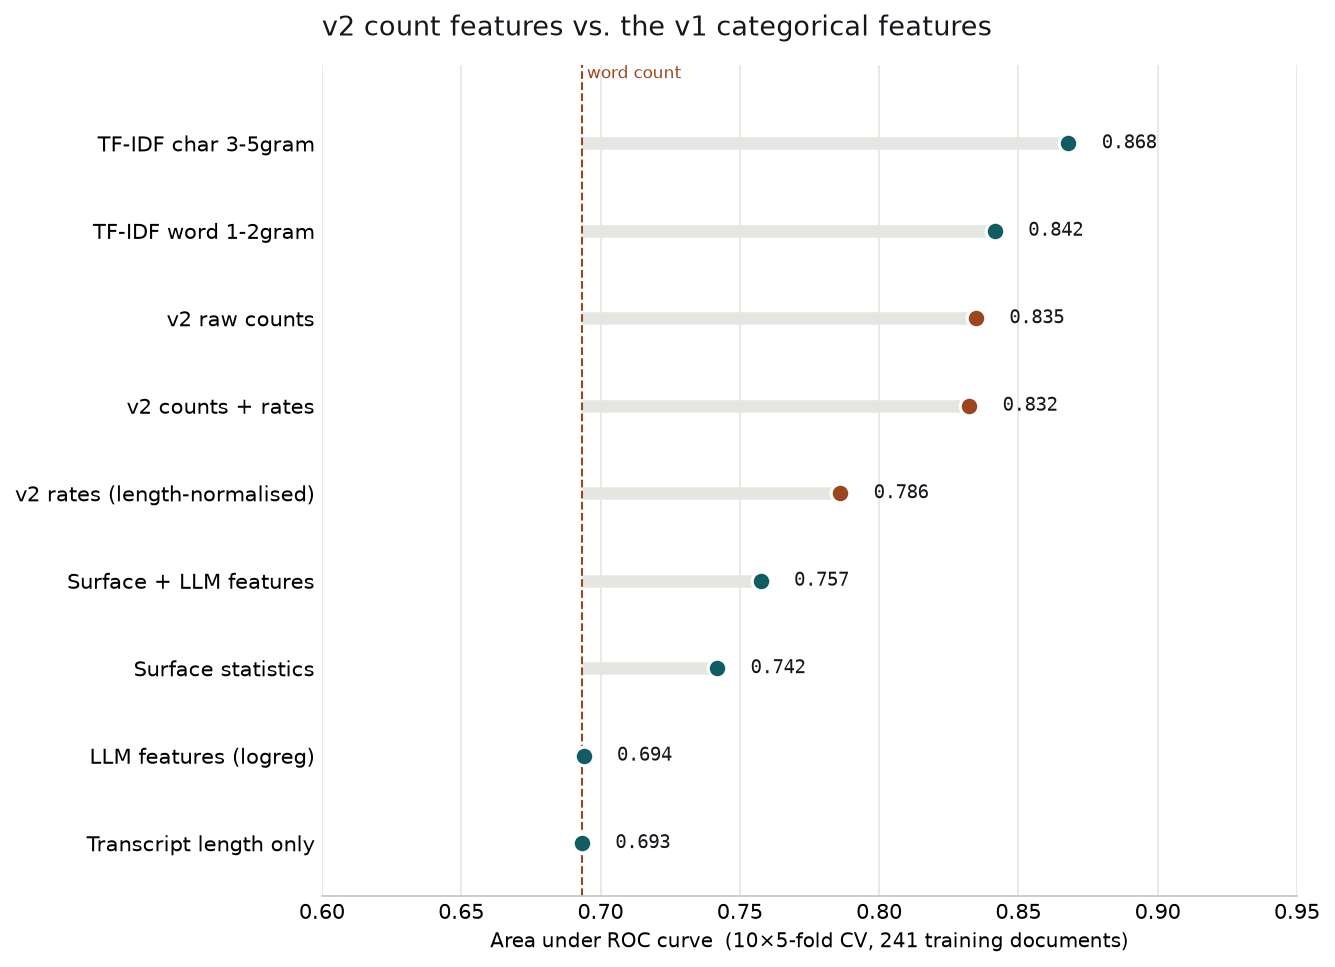

In [11]:
import matplotlib.pyplot as plt

base = pd.read_csv("outputs/baseline_results.csv")
keep = ["Transcript length only", "Surface statistics", "LLM features (logreg)",
        "Surface + LLM features", "TF-IDF word 1-2gram", "TF-IDF char 3-5gram"]
combined = pd.concat([
    base[base.representation.isin(keep)][["representation", "auc"]],
    comparison[comparison.representation.str.startswith("v2")][["representation", "auc"]],
]).sort_values("auc").reset_index(drop=True)

length_auc = float(base.loc[base.representation == "Transcript length only", "auc"].iloc[0])
INK, ACCENT, V2C, MUTED, WARN = "#14181C", "#125C63", "#9B4620", "#9AA39F", "#9B4620"

fig, ax = plt.subplots(figsize=(9, 0.55 * len(combined) + 1.6), dpi=150)
for i, r in combined.iterrows():
    is_v2 = r.representation.startswith("v2")
    ax.plot([length_auc, r.auc], [i, i], color="#E3E6E1", lw=6, solid_capstyle="butt", zorder=1)
    ax.scatter(r.auc, i, s=80, color=V2C if is_v2 else ACCENT, zorder=3,
               edgecolor="white", linewidth=1.5)
    ax.text(r.auc + 0.012, i, f"{r.auc:.3f}", va="center", fontsize=9,
            color=INK, family="monospace")

ax.axvline(length_auc, color=WARN, ls="--", lw=1, zorder=2)
ax.text(length_auc, len(combined) - 0.3, " word count", fontsize=8, color=WARN, va="bottom")
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined.representation, fontsize=10)
ax.set_xlabel("Area under ROC curve  (10×5-fold CV, 241 training documents)", fontsize=9.5)
ax.set_xlim(0.60, 0.95)
ax.set_ylim(-0.6, len(combined) - 0.1)
ax.grid(axis="x", color="#E3E6E1", lw=0.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#C2C7BE"); ax.tick_params(length=0)
ax.set_title("v2 count features vs. the v1 categorical features",
             fontsize=13, loc="left", pad=14, color=INK)
plt.tight_layout()
plt.savefig("outputs/comparison_with_v2.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

Orange marks the proposed v2 representation. The dashed line is transcript length: the honest
threshold any representation has to clear before it can be said to measure language rather
than verbosity.